In [1]:
import pandas as pd
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv('datasets/hour.csv')

In [3]:
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
data.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [6]:
num_cols = [col for col in data.columns if data[col].dtypes != "O"]

In [7]:
num_cols

['instant',
 'season',
 'yr',
 'mnth',
 'hr',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'casual',
 'registered',
 'cnt']

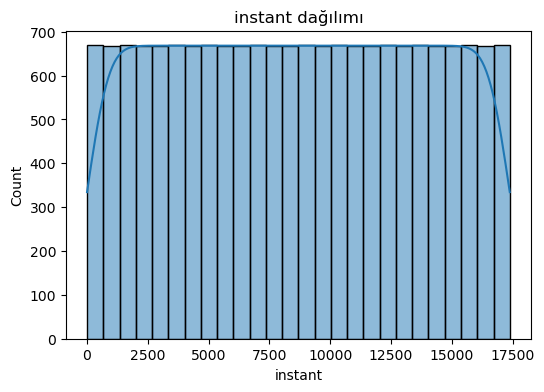

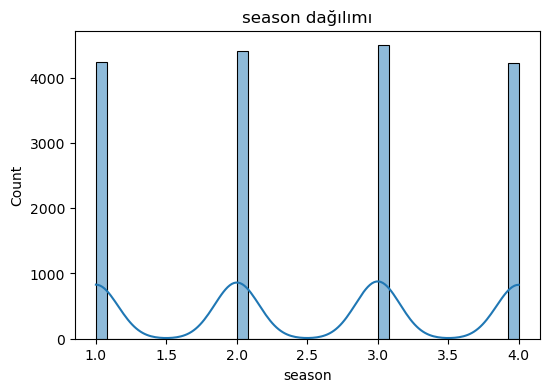

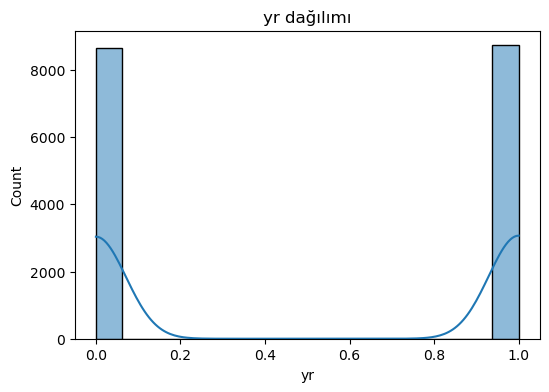

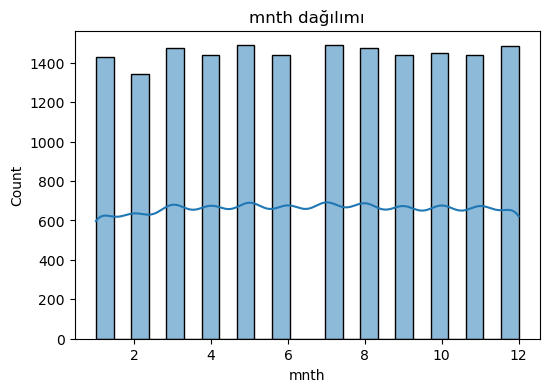

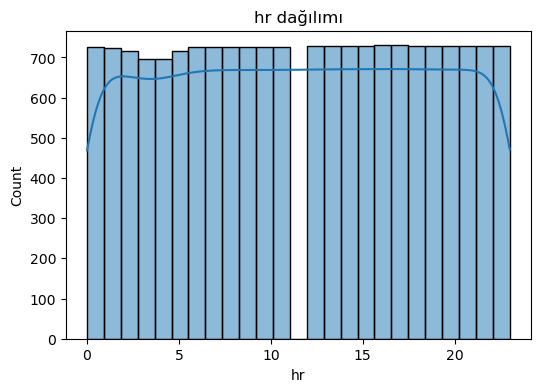

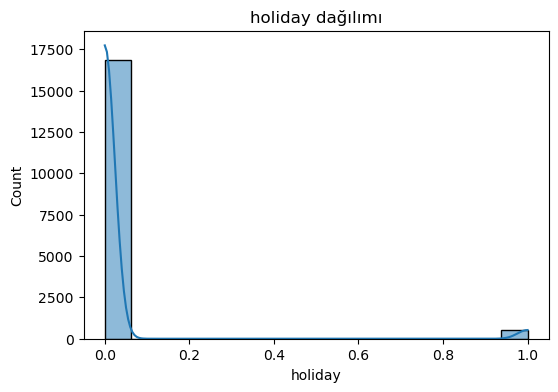

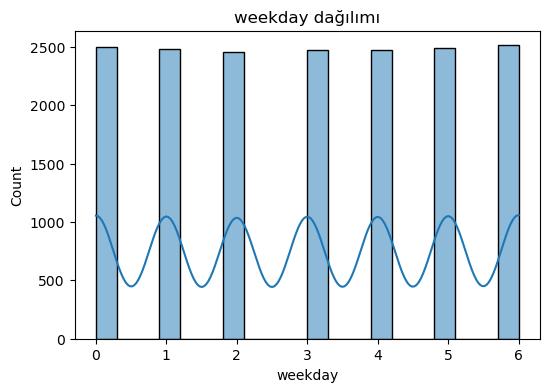

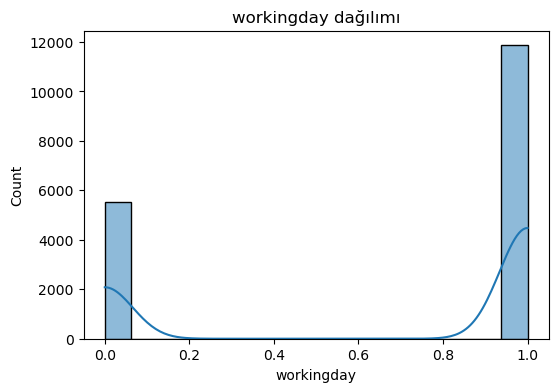

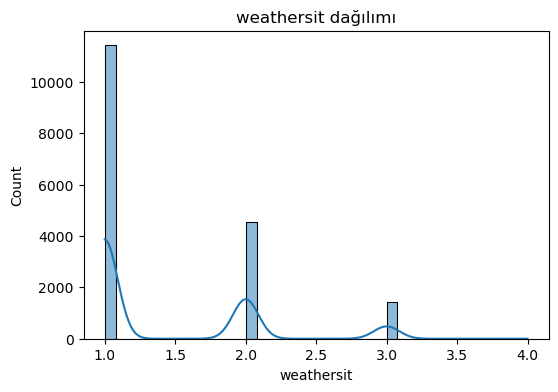

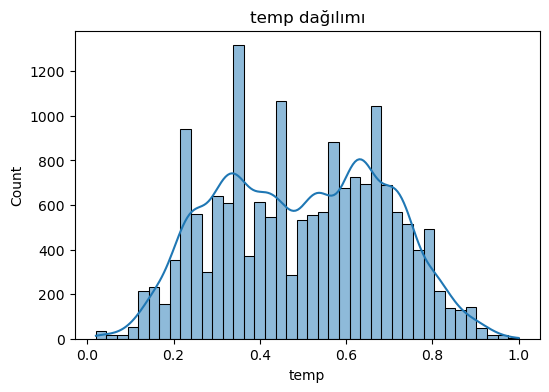

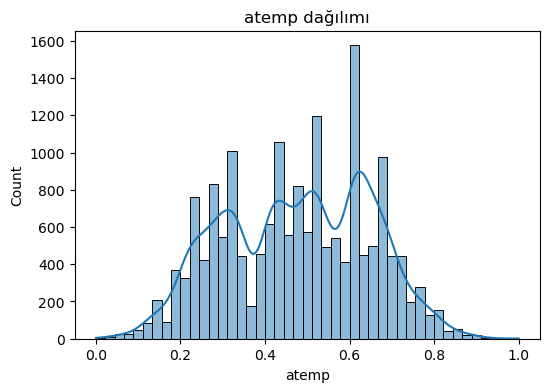

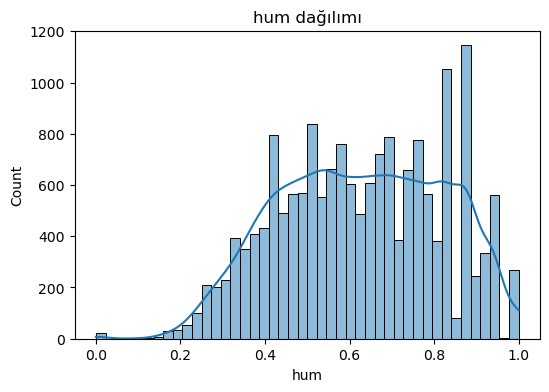

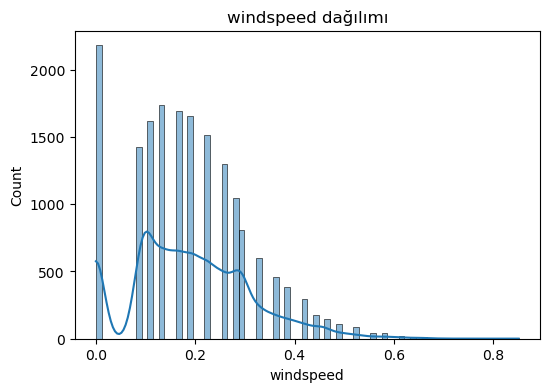

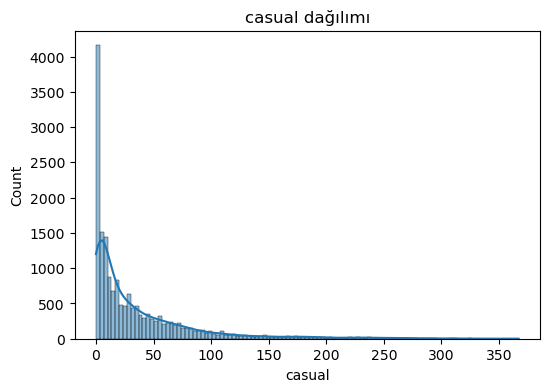

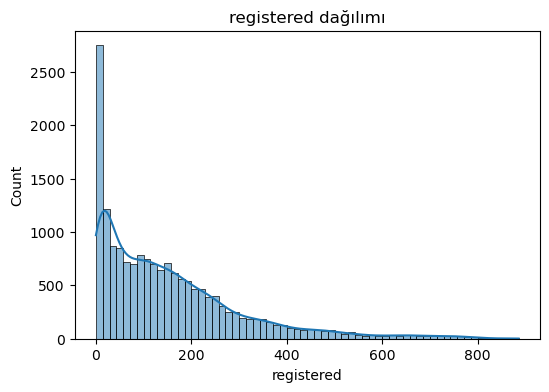

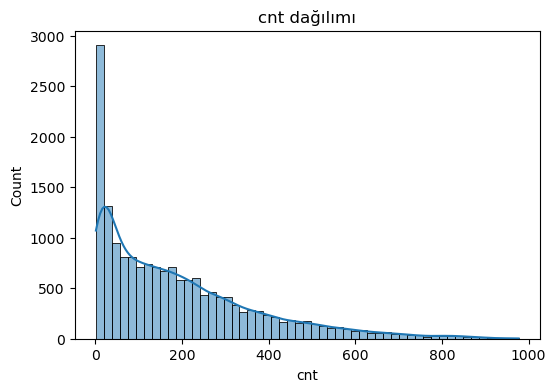

In [8]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col],kde=True)#histplot histogram çizer (x ekseni degerler y ekseni frekans kaç tane var)
    #kde kernel density estimation
    plt.title(f"{col} dağılımı")
    plt.show()


In [9]:
corr = data[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].corr()
(corr)

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.987672,-0.069881,-0.023125,0.459616,0.335361,0.404772
atemp,0.987672,1.000000,-0.051918,-0.062336,0.454080,0.332559,0.400929
hum,-0.069881,-0.051918,1.000000,-0.290105,-0.347028,-0.273933,-0.322911
windspeed,-0.023125,-0.062336,-0.290105,1.000000,0.090287,0.082321,0.093234
casual,0.459616,0.454080,-0.347028,0.090287,1.000000,0.506618,0.694564
registered,0.335361,0.332559,-0.273933,0.082321,0.506618,1.000000,0.972151
cnt,0.404772,0.400929,-0.322911,0.093234,0.694564,0.972151,1.000000


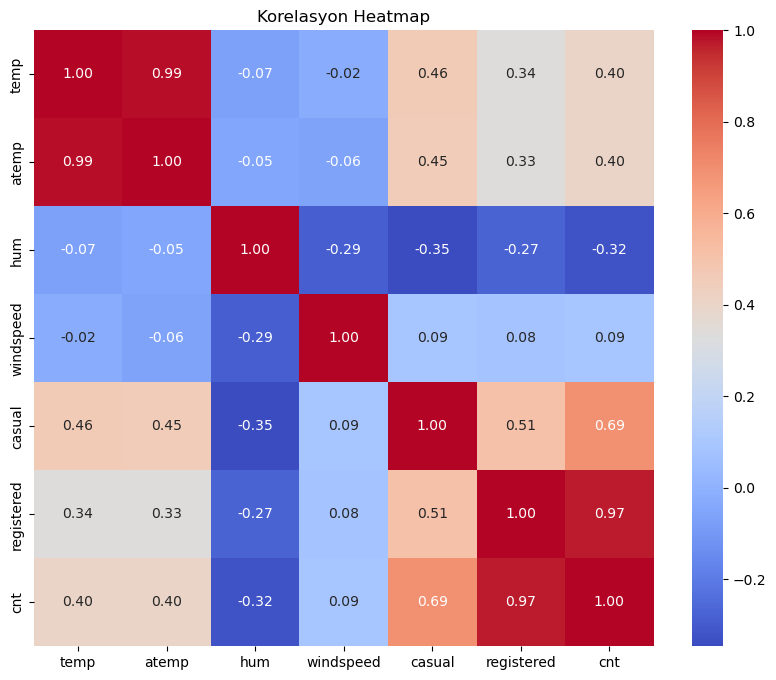

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasyon Heatmap")
plt.show()

**REGRESYON**


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, model_selection

In [12]:
data = pd.read_csv("/Users/semra/ML-For-Beginners/2-Regression/3-Linear/bike_sharing_dataset/datasets/hour.csv")
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [22]:
def grab_col_names(dataframe, cat_th = 15, car_th = 20 ):#cat treshld ve kardinal threshold belirlenmiş

    #cat_cols , cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    #ilgili değişkendekii eşsiz değer sayısına bak eger bu
    # belirlediğin tresholddan kucukse ve değişkenin tipi de obje değilse numerik ama kategorik

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    #eşsiz sınıf sayısı 20 den butyukse ve tipi de kategorikse kategorik ama kardinal
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat#at cols listesi guncellendi
    cat_cols = [col for col in cat_cols if col not in cat_but_car]#cat cols içindeki kardinalleri cıkar

    #num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"] #tipi objectten farklı olanları getirdik int ya da float olanlar geldi
    num_cols = [col for col in num_cols if col not in num_but_cat] #numerik ama kategorik olanları da içinden cıkarıyoruz içinde sadece numerik kolonlar kalıyor

    print(f"observation : {dataframe.shape[0]}")
    print(f"variables : {dataframe.shape[1]}")
    print(f"cat_cols : {len(cat_cols)}")
    print(f"num_cols : {len(num_cols)}")
    print(f"cat_but_car : {len(cat_but_car)}")
    print(f"num_but_cat : {len(num_but_cat)}")
    return cat_cols, num_cols, cat_but_car #gercek numerik gercek kategorik ve gercek kardinaller kaldı


In [23]:
cat_cols, num_cols, cat_but_car = grab_col_names(data)


observation : 17379
variables : 17
cat_cols : 7
num_cols : 9
cat_but_car : 1
num_but_cat : 7


In [24]:
num_cols

['instant',
 'hr',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'casual',
 'registered',
 'cnt']

In [37]:
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000
hum,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.8507
casual,17379.0,35.676218,49.305030,0.00,4.0000,17.0000,48.0000,367.0000
registered,17379.0,153.786869,151.357286,0.00,34.0000,115.0000,220.0000,886.0000
cnt,17379.0,189.463088,181.387599,1.00,40.0000,142.0000,281.0000,977.0000


In [55]:
corr_matrix =data[num_cols].corr()
corr_with_target = corr_matrix['cnt'].abs()
selected_cols = corr_with_target[corr_with_target > 0.4].index
selected_cols

Index(['temp', 'atemp', 'casual', 'registered', 'cnt'], dtype='object')

In [49]:
corr = corr_matrix['cnt'].abs().sort_values(ascending=False).index
corr


Index(['cnt', 'registered', 'casual', 'temp', 'atemp', 'hr', 'hum', 'instant',
       'windspeed'],
      dtype='object')

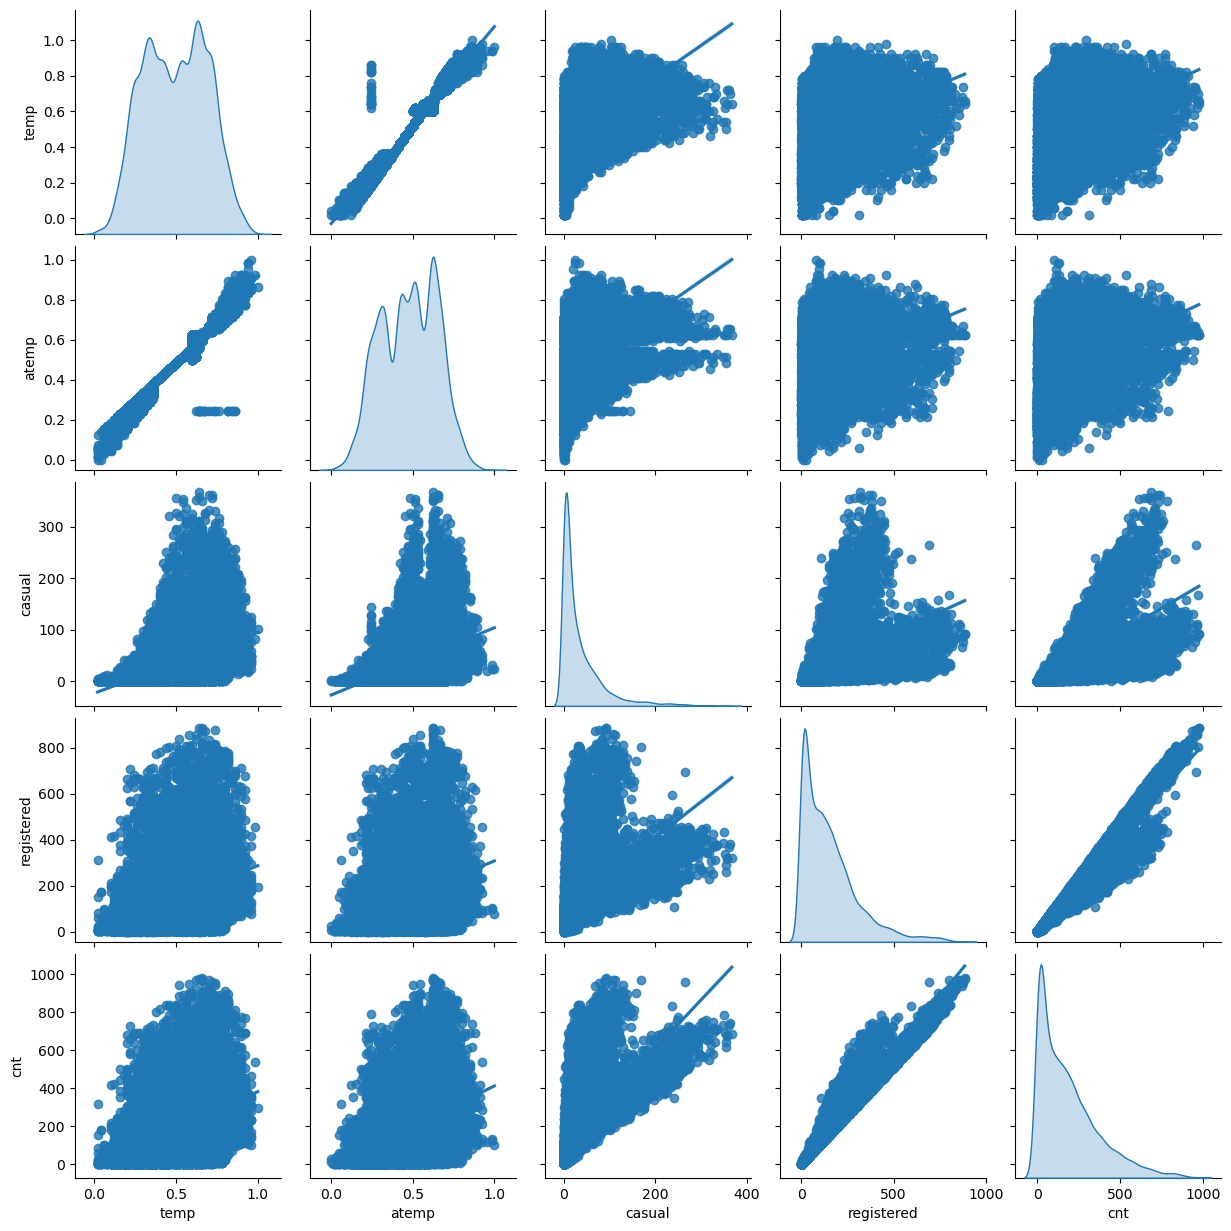

In [62]:
sns.pairplot(data[selected_cols], kind  ="reg", diag_kind="kde");#korelasyonları göster

In [83]:
columns_to_select = ['atemp', 'casual','windspeed', 'hr' ,'cnt']

In [85]:
for col in columns_to_select:
    print(f"Correlation between {col} and cnt: {data[col].corr(data['cnt'])}")

Correlation between atemp and cnt: 0.40092930412663197
Correlation between casual and cnt: 0.6945640779749489
Correlation between windspeed and cnt: 0.09323378392612536
Correlation between hr and cnt: 0.39407149778294315
Correlation between cnt and cnt: 1.0


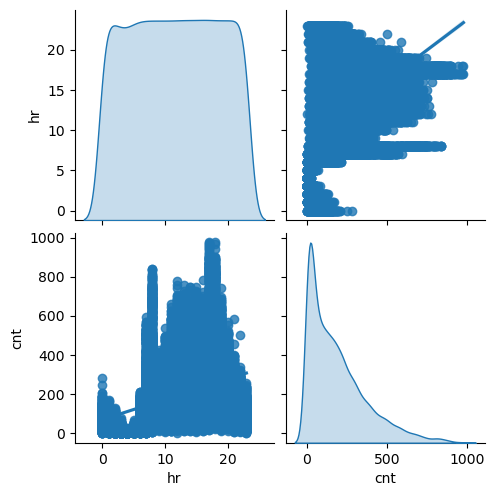

In [79]:
sns.pairplot(data[['hr', 'cnt']], kind="reg", diag_kind="kde");#korelasyonları göster

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [188]:
X = data[['casual']].to_numpy().reshape(-1,1)
y = data['cnt']
X.shape
y.shape


(17379,)

In [189]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [190]:
lin_reg = LinearRegression()

In [191]:
lin_reg.fit(X_train, y_train)

LinearRegression()

In [192]:
pred = lin_reg.predict(X_test)
pred

array([570.16607763, 111.59487033, 101.40439906, ..., 119.23772379,
       307.76144234, 111.59487033])

In [193]:
#mean square error hesapla
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 127.64122906615796


In [ ]:
#coeffient of determination
score = lin_reg.score(X_train, y_train)
print("model determination:",score)

"""
hr --> 0.1535
atemp --> 0.1593
casual --> 0.4816
windspeed --> 0.0078
"""

model determination: 0.4815828659624717


'\nhr --> 0.1535\natemp --> 0.1593\ncasual --> \nwindspeed --> 0.0078\n'

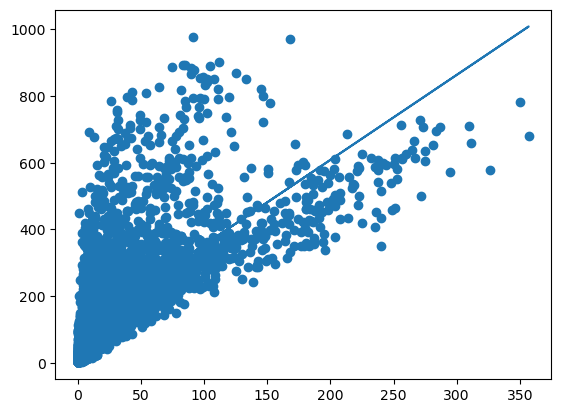

In [195]:
#test datası ile scatter plot yap
plt.scatter(X_test, y_test)

plt.plot(X_test, pred)

mean error : 1.62e+02 (85.6%)


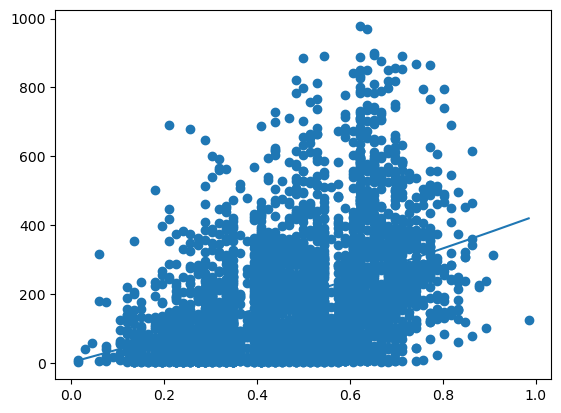

In [162]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

#polinomal regresyon pipelineı olusturma
pipeline = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

#modeli inşa etmek için kullan
pipeline.fit(X_train, y_train)

#modeli test et
pred = pipeline.predict(X_test)

#mean square error hesapla
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f"mean error : {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)")

#plot the result
plt.scatter(X_test, y_test)
plt.plot(sorted(X_test),pipeline.predict(sorted(X_test)))


In [ ]:
#model skoru
score = pipeline.score(X_train, y_train)
print("model determination:",score)

"""
windspeed --> 0.0116
casual 0.54 
hr --> 0.298
atemp --> 0.1594

"""

model determination: 0.15940613655350555


'\nwindspeed --> 0.0116\ncasual 0.54 \nhr --> 0.298\natemp --> \n\n'

<Axes: xlabel='season', ylabel='cnt'>

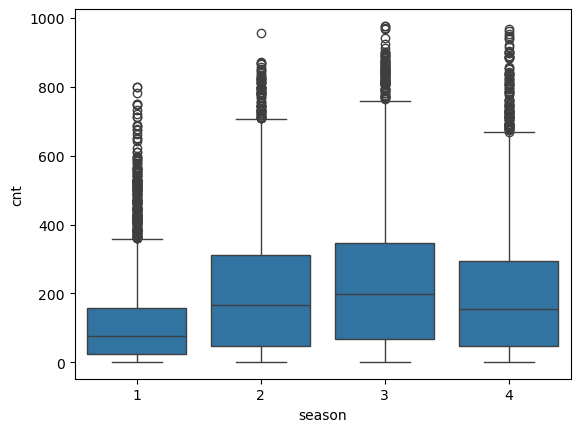

In [110]:
sns.boxplot(x='season', y='cnt', data=data)


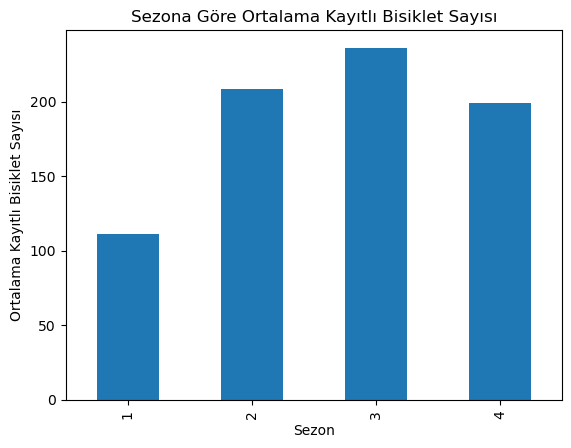

In [111]:
data.groupby('season')['cnt'].mean().plot(kind='bar')
plt.title('Sezona Göre Ortalama Kayıtlı Bisiklet Sayısı')
plt.xlabel('Sezon')
plt.ylabel('Ortalama Kayıtlı Bisiklet Sayısı')
plt.show()

In [112]:
from sklearn.preprocessing import OneHotEncoder
season_dummies = pd.get_dummies(data['season'], prefix='season')
df_reg = pd.concat([season_dummies, data['cnt']], axis=1)


In [113]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()   # ← model burada tanımlanır



In [72]:
X = df_reg.drop('cnt', axis=1)
y = df_reg['cnt']

lin_reg.fit(X, y)


LinearRegression()

In [73]:
lin_reg.coef_


array([-77.47136403,  19.75813632,  47.43030402,  10.2829237 ])

In [74]:
pd.Series(lin_reg.coef_, index=X.columns)



season_1   -77.471364
season_2    19.758136
season_3    47.430304
season_4    10.282924
dtype: float64

In [75]:
lin_reg.score(X, y)


0.06598791920074698

In [196]:
#holiday ve workingday lojistik regresyon için inceleme

In [197]:
cat_cols

['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

In [229]:
binary_cols = ['holiday', 'workingday']
data['workingday'].value_counts()


workingday
1    11865
0     5514
Name: count, dtype: int64

In [230]:
sns.pairplot(data[binary_cols], kind  ="reg", diag_kind="kde");#korelasyonları göster

In [231]:
for col in binary_cols:
    print(f"Correlation between {col} and cnt: {data[col].corr(data['cnt'])}")

#dusuk korelasyon

Correlation between holiday and cnt: -0.030927303249110697
Correlation between workingday and cnt: 0.030284367747908734


In [235]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

X = data[binary_cols]

# cnt'yi binary hale getiriyoruz
# ortalamanın üstü = 1, altı = 0
y = (data['cnt'] > data['cnt'].median()).astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print('Predicted labels: ', predictions)
print('F1-score: ', f1_score(y_test, predictions))



              precision    recall  f1-score   support

           0       0.56      0.36      0.44      1740
           1       0.53      0.71      0.61      1736

    accuracy                           0.54      3476
   macro avg       0.54      0.54      0.52      3476
weighted avg       0.54      0.54      0.52      3476

Predicted labels:  [0 1 1 ... 1 0 1]
F1-score:  0.6052438127909826


In [236]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[ 630, 1110],
       [ 501, 1235]])

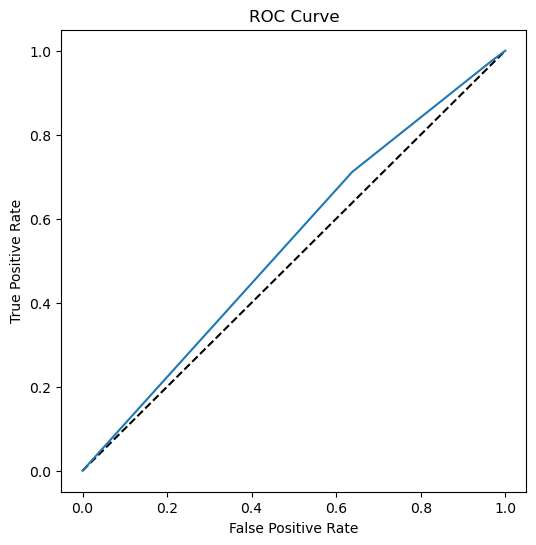

In [238]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1778
           1       0.77      0.77      0.77      1698

    accuracy                           0.78      3476
   macro avg       0.78      0.78      0.78      3476
weighted avg       0.78      0.78      0.78      3476

F1-score:  0.7712264150943396


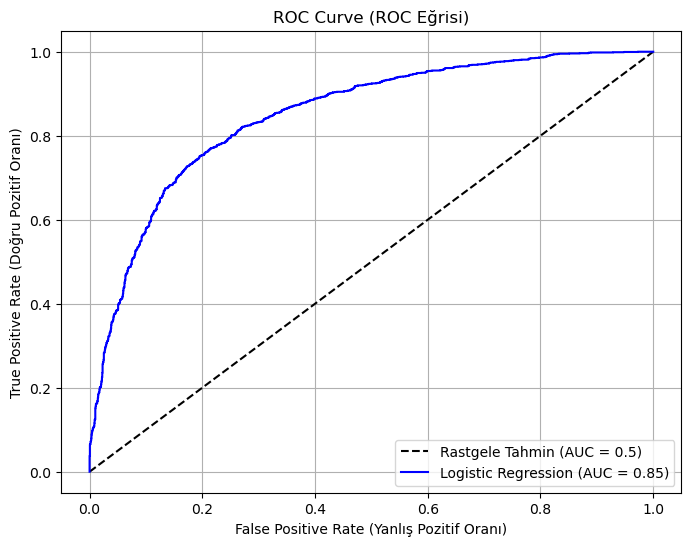

In [239]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

# 1. ÖZELLİK SEÇİMİ (Feature Engineering)
# Sadece binary olanları değil, sonucu etkileyen asıl sayısal değerleri de ekliyoruz.
# 'temp': Sıcaklık, 'hum': Nem, 'season': Mevsim, 'hr': Saat (eğer saatlik veriyse)
features = ['holiday', 'workingday', 'temp', 'atemp', 'hum', 'season'] 

# Eğer elindeki veri saatlikse 'hr' (saat) kolonu çok kritiktir, mutlaka ekle:
if 'hr' in data.columns:
    features.append('hr')

X = data[features]

# 2. HEDEF DEĞİŞKEN (Target)
# Bisiklet sayısı medyanın üzerindeyse 1 (Yüksek), altındaysa 0 (Düşük)
y = (data['cnt'] > data['cnt'].median()).astype(int)

# 3. VERİ SETİNİ BÖLME
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. MODEL EĞİTİMİ
# iter_max hatası almamak için iterasyon sayısını biraz artırdık
model = LogisticRegression(max_iter=1000) 
model.fit(X_train, y_train)

# 5. TAHMİNLER
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1] # 1 sınıfının (Yüksek) olasılığı

# 6. SONUÇLARI YAZDIRMA
print("--- Sınıflandırma Raporu ---")
print(classification_report(y_test, predictions))
print('F1-score: ', f1_score(y_test, predictions))

# 7. ROC EĞRİSİ GRAFİĞİ
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
# Rastgele tahmin çizgisi (Başarısız model)
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin (AUC = 0.5)')
# Bizim modelimiz
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})', color='blue')

plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Curve (ROC Eğrisi)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()